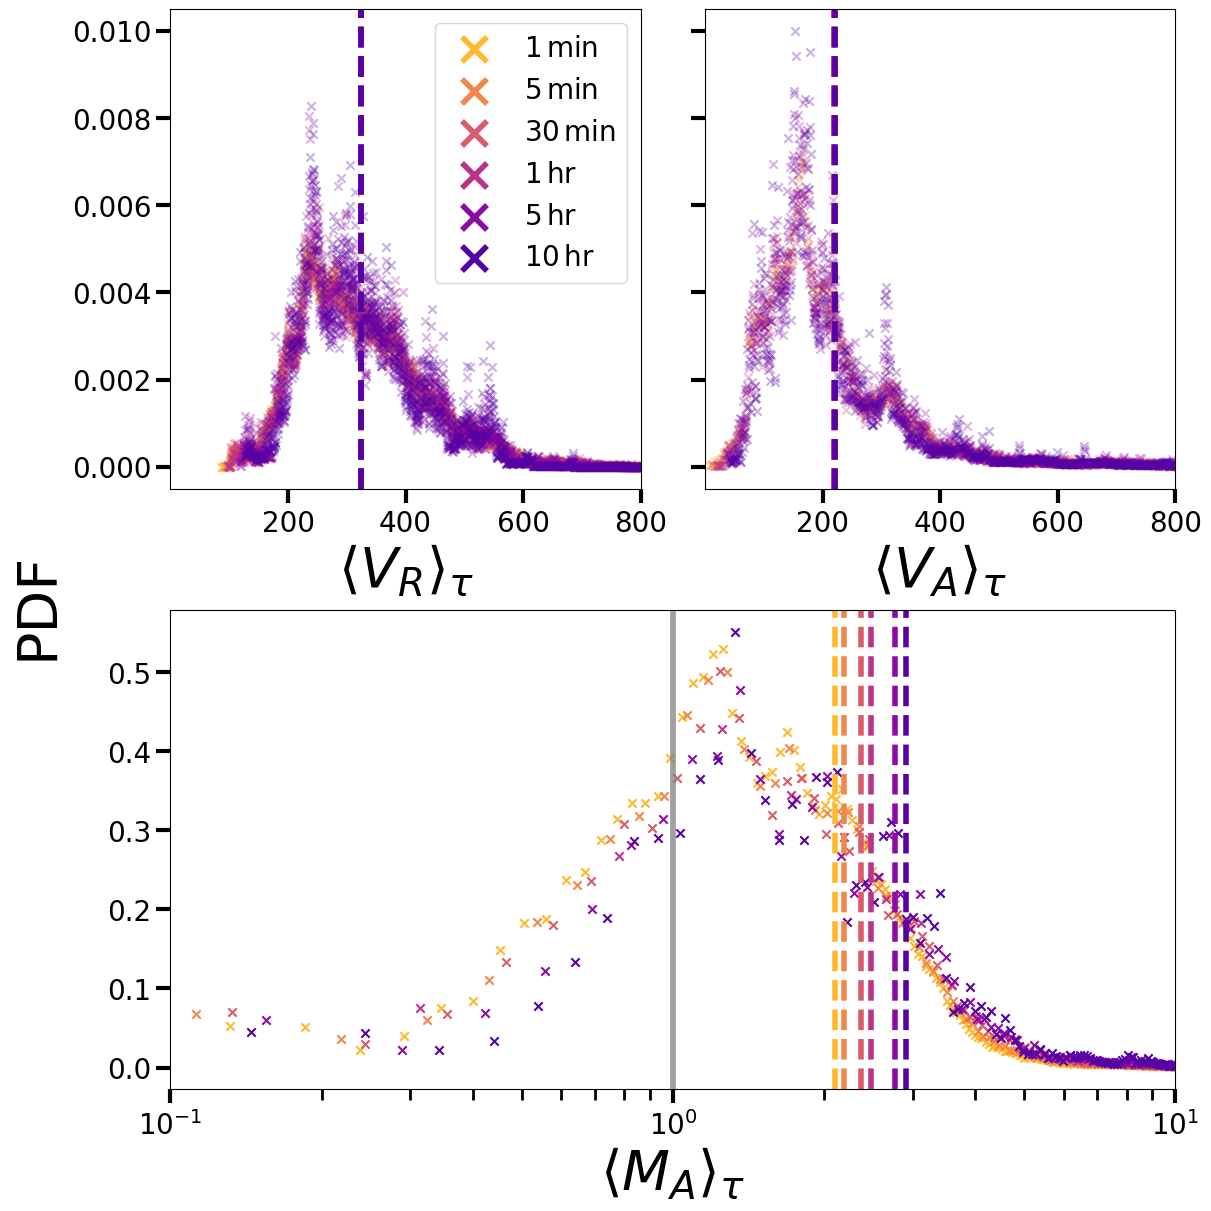

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import importlib
from scipy.ndimage import gaussian_filter
import encs as E
importlib.reload(E)


plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 1,
    'axes.labelsize': 40,
    'xtick.labelsize': 20,
    'xtick.major.pad': 5,
    'xtick.major.size':    3.5,
    'xtick.minor.size':    2,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 18,
    'xtick.major.size':    10,
    'xtick.minor.size':    8,
    'ytick.major.size':    10,
    'ytick.minor.size':    8,
    'xtick.major.width':   3,
    'xtick.minor.width':   2,
    'ytick.major.width':   3,
    'ytick.minor.width':   2,
})

avg = 'mean'

figsave = f'fig/MA_pdf.png'

fig = plt.figure(figsize=(12, 12), layout="constrained")

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1],
)


ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)  # shares y-axis with ax0
ax2 = fig.add_subplot(gs[1, :])     # independent y-axis

ax = [ax0, ax1, ax2]

# cad = ['60s', '5min', '30min', '1h', '5h', '10h']
cadences = ['1min', '5min', '30min', '1h', '5h', '10h']
cad_lab = [r'$1\,\rm{min}$', r'$5\,\rm{min}$', r'$30\,\rm{min}$', r'$1\,\rm{hr}$', r'$5\,\rm{hr}$', r'$10\,\rm{hr}$']

cmap = plt.get_cmap('plasma_r')  # or 'plasma', 'magma', 'cividis', 'turbo'
vals = np.linspace(0.15, 0.85, len(cadences))

colors = {
    cadence: cmap(v)
    for cadence, v in zip(cadences, vals)
}

# cad = ['60s']
# cols = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple']
# cols = ['blue']
enc_range=np.arange(8,20)
# rm = np.where(enc_range == 15)
# enc_range = np.delete(enc_range, rm)
i = 0
for cadence, c in colors.items():
    # df = E.load_all_encounters(enc_range, res=10, avg = cadence)
    df = E.load_all_encounters(enc_range, res=10).dropna()
    df = df[(df['n'] > 0) & (df['n'] < 1e15)]

    df['VA'] = E.VA(df).dropna()
    if avg == 'mean':
        df = df.rolling(cadence, center = True).mean()
    elif avg == 'med':
        df = df.rolling(cadence, center = True).median()
    df['MA'] = E.M_A(df).dropna()
    # df['MA'] = df[df['MA'] < 1e3]['MA']
    
    # df = df[np.isfinite(df['VA'])]
    var = df['VR']
    n = 0
    counts, bin_edges = np.histogram(var, bins=1500, density = True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    n_bins = len(bin_edges) - 1
    # ax[n].hist(var, bins=bin_edges, log = True, histtype='step',
    #     label=f"{cadence} ({n_bins} bins)", lw = 4, color = c, density= True)
    # ax[n].plot(bin_centers, counts, lw=1.5, marker='x', markevery = 15, ms=3, label = f"{cadence}" , c = c)
    ax[n].scatter(bin_centers, counts, lw=1.5, marker='x', label = cad_lab[i], color = c, alpha = 0.3)
    mean = np.mean(var)
    # print(mean)
    # ax[n].scatter(bin_centers, counts, color=c, marker='x', label=f"{cadence} ({n_bins} bins)")
    # max_index = np.argmax(counts)
    # max_bin_start = bin_edges[max_index]
    # max_bin_end = bin_edges[max_index + 1]
    # most_prob = (max_bin_start + max_bin_end)/2
    ax[n].axvline(mean, color = c, lw = 4, ls = '--')
    # ax[n].axvline(np.mean(var), color = c, lw = 4)
    ax[n].set_xlim(1e-1, 8e2)
    leg = ax[n].legend(markerscale=3)
    for handle in leg.legend_handles:
        handle.set_linewidth(4)
        handle.set_alpha(1.0)
    ax[n].set_xlabel(r'$\langle V_R \rangle_{\tau}$')
    # ax[n].set_ylabel(r'PDF')
    
    var = df['VA'].dropna()
    n = 1
    counts, bin_edges = np.histogram(var, bins=1500, density = True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    n_bins = len(bin_edges) - 1
    # ax[n].scatter(bin_centers, counts, color=c, marker='x', label=f"{cadence} ({n_bins} bins)")
    # ax[n].plot(bin_centers, counts, lw=1.5, marker='x', markevery = 15, ms=3, label = f"{cadence}", c = c)
    ax[n].scatter(bin_centers, counts, lw=1.5, marker='x', label = cad_lab[i], color = c, alpha = 0.3)
    mean = np.mean(var)
    # max_index = np.argmax(counts)
    # max_bin_start = bin_edges[max_index]
    # max_bin_end = bin_edges[max_index + 1]
    # most_prob = (max_bin_start + max_bin_end)/2
    ax[n].axvline(mean, color = c, lw = 4, ls = '--')

    # ax[n].axvline(np.mean(var), color = c, lw = 4)
    ax[n].set_xlim(1e-1, 800)
    # ax[n].legend()
    ax[n].set_xlabel(r'$\langle V_A \rangle_{\tau}$')
    # ax[n].set_ylabel(r'PDF')
    
    var = df['MA'].dropna()
    # print(cadence)
    # print(var)
    n = 2
    counts, bin_edges = np.histogram(var, bins=1500, density = True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    n_bins = len(bin_edges) - 1
    # ax[n].scatter(bin_centers, counts, color=c, marker='x', label=f"{cadence}")
    # ax[n].plot(bin_centers, counts, lw=1.5, marker='x', markevery = 15, ms=3, label = f"{cadence}", c = c )
    ax[n].scatter(bin_centers, counts, lw=1.5, marker='x', label = cad_lab[i], color = c)
    mean = np.mean(var)
    # max_index = np.argmax(counts)
    # max_bin_start = bin_edges[max_index]
    # max_bin_end = bin_edges[max_index + 1]
    # most_prob = (max_bin_start + max_bin_end)/2
    ax[n].axvline(1, color = 'gray', lw = 4, alpha = 0.2)
    ax[n].axvline(mean, color = c, lw = 4, ls = '--')
    

    # ax[n].axvline(np.mean(var), color = c, lw = 4)
    ax[n].set_xlim(1e-1, 10)
    ax[n].set_xscale('log')
    # ax[n].set_ylabel(r'PDF')
    # ax[n].set_ylim(1e-4, 10)

    
    
    ax[n].set_xlabel(r'$\langle M_A \rangle_{\tau}$')
    i = i + 1

    # ax[n].set_ylabel(r'PDF')
ax1.tick_params(labelleft=False)
# ticks = ax[2].get_xticks()          # get existing ticks
# ticks = np.append(ticks, 1)      # add 1
# ticks = np.unique(ticks)         # remove duplicates + sort
# ticks = np.delete(ticks, 0)
# ax[2].set_xticks(ticks)

fig.supylabel(r'PDF', fontsize = 40)
fig.savefig(figsave, bbox_inches="tight", dpi = 500)
# plt.close()